In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat data dummy logistik_pengiriman.csv secara otomatis (anti-error)
np.random.seed(42)
n_samples = 150

id_pengiriman = [f'DEL-{2000+i}' for i in range(n_samples)]
pemasok = np.random.choice(['PT Jaya Teknik', 'CV Logistik Maju', 'PT Komponen Utama', 'PT Bina Mandiri', 'CV Sinar Utama'], size=n_samples)
kota_asal = np.random.choice(['Surabaya', 'Semarang', 'Bandung', 'Medan', 'Makassar'], size=n_samples)
jarak = np.random.randint(100, 1200, size=n_samples)
moda = np.random.choice(['Truk', 'Kereta', 'Kapal Laut'], size=n_samples)

tgl_pesan = pd.date_range(start='2024-01-01', periods=n_samples, freq='D')
estimasi_hari = np.random.randint(2, 8, size=n_samples)
tgl_tiba_rencana = tgl_pesan + pd.to_timedelta(estimasi_hari, unit='D')

# Simulasi keterlambatan/kecepatan pengiriman (selisih hari)
selisih = np.random.choice([-2, -1, 0, 1, 2, 3, 5], size=n_samples, p=[0.1, 0.15, 0.4, 0.15, 0.1, 0.05, 0.05])
tgl_tiba_aktual = tgl_tiba_rencana + pd.to_timedelta(selisih, unit='D')
biaya = jarak * np.random.uniform(15, 25, size=n_samples) + np.random.uniform(500, 2000, size=n_samples)

df = pd.DataFrame({
    'ID_Pengiriman': id_pengiriman,
    'Nama_Pemasok': pemasok,
    'Kota_Asal': kota_asal,
    'Jarak_KM': jarak,
    'Moda_Transportasi': moda,
    'Tanggal_Pesan': tgl_pesan,
    'Tanggal_Tiba_Rencana': tgl_tiba_rencana,
    'Tanggal_Tiba_Aktual': tgl_tiba_aktual,
    'Selisih_Hari': selisih,
    'Biaya_Pengiriman_Ribu_Rupiah': biaya
})

# Menyimulasikan data in-transit (Tanggal_Tiba_Aktual & Selisih_Hari kosong)
in_transit_idx = [10, 25, 42, 67, 89, 112, 135]
df.loc[in_transit_idx, 'Tanggal_Tiba_Aktual'] = pd.NaT
df.loc[in_transit_idx, 'Selisih_Hari'] = np.nan

# Simpan ke CSV lokal
df.to_csv('logistik_pengiriman.csv', index=False)

# Tampilkan dimensi dan 10 baris pertama
print("Dimensi Data (Baris, Kolom):", df.shape)
df.head(10)

Dimensi Data (Baris, Kolom): (150, 10)


,ID_Pengiriman,Nama_Pemasok,Kota_Asal,Jarak_KM,Moda_Transportasi,Tanggal_Pesan,Tanggal_Tiba_Rencana,Tanggal_Tiba_Aktual,Selisih_Hari,Biaya_Pengiriman_Ribu_Rupiah
0,DEL-2000,PT Bina Mandiri,Surabaya,1160,Truk,2024-01-01,2024-01-03,2024-01-04,1.0,28002.214612
1,DEL-2001,CV Sinar Utama,Surabaya,379,Truk,2024-01-02,2024-01-08,2024-01-06,-2.0,9693.085691
2,DEL-2002,PT Komponen Utama,Surabaya,596,Truk,2024-01-03,2024-01-10,2024-01-08,-2.0,10845.143371
3,DEL-2003,CV Sinar Utama,Surabaya,401,Truk,2024-01-04,2024-01-11,2024-01-11,0.0,8218.385720
4,DEL-2004,CV Sinar Utama,Bandung,280,Truk,2024-01-05,2024-01-09,2024-01-09,0.0,7367.097448
5,DEL-2005,CV Logistik Maju,Surabaya,706,Kereta,2024-01-06,2024-01-08,2024-01-07,-1.0,18008.441750
6,DEL-2006,PT Komponen Utama,Medan,799,Truk,2024-01-07,2024-01-11,2024-01-11,0.0,15865.575969
7,DEL-2007,PT Komponen Utama,Makassar,1092,Truk,2024-01-08,2024-01-13,2024-01-13,0.0,24635.499623
8,DEL-2008,PT Komponen Utama,Surabaya,290,Kapal Laut,2024-01-09,2024-01-12,2024-01-12,0.0,7665.730361
9,DEL-2009,CV Sinar Utama,Bandung,352,Truk,2024-01-10,2024-01-17,2024-01-17,0.0,8452.078721


In [2]:
# Inspeksi Struktur & Tipe Data
print("=== INFORMASI STRUKTUR DATA ===")
df.info()

print("\n=== PEMERIKSAAN DATA IN-TRANSIT (MISSING VALUE SELISIH HARI) ===")
in_transit_df = df[df['Selisih_Hari'].isnull()]
completed_df = df[df['Selisih_Hari'].notnull()].copy()

print(f"Jumlah Pengiriman Selesai (Completed) : {len(completed_df)} baris")
print(f"Jumlah Pengiriman Dalam Proses (In-Transit) : {len(in_transit_df)} baris")

=== INFORMASI STRUKTUR DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID_Pengiriman                 150 non-null    str           
 1   Nama_Pemasok                  150 non-null    str           
 2   Kota_Asal                     150 non-null    str           
 3   Jarak_KM                      150 non-null    int32         
 4   Moda_Transportasi             150 non-null    str           
 5   Tanggal_Pesan                 150 non-null    datetime64[us]
 6   Tanggal_Tiba_Rencana          150 non-null    datetime64[us]
 7   Tanggal_Tiba_Aktual           143 non-null    datetime64[us]
 8   Selisih_Hari                  143 non-null    float64       
 9   Biaya_Pengiriman_Ribu_Rupiah  150 non-null    float64       
dtypes: datetime64[us](3), float64(2), int32(1), str(4)
memory usage: 11.3 KB

===

In [3]:
# Pengategorian status ketepatan waktu pengiriman
def kategorikan_status(row):
    if row['Selisih_Hari'] > 0:
        return 'Terlambat'
    elif row['Selisih_Hari'] == 0:
        return 'Tepat Waktu'
    else:
        return 'Lebih Awal'

completed_df['Status_Pengiriman'] = completed_df.apply(kategorikan_status, axis=1)

# Ringkasan status
print("=== DISTRIBUSI STATUS PENGIRIMAN ===")
print(completed_df['Status_Pengiriman'].value_counts())

=== DISTRIBUSI STATUS PENGIRIMAN ===
Status_Pengiriman
Tepat Waktu    57
Terlambat      47
Lebih Awal     39
Name: count, dtype: int64


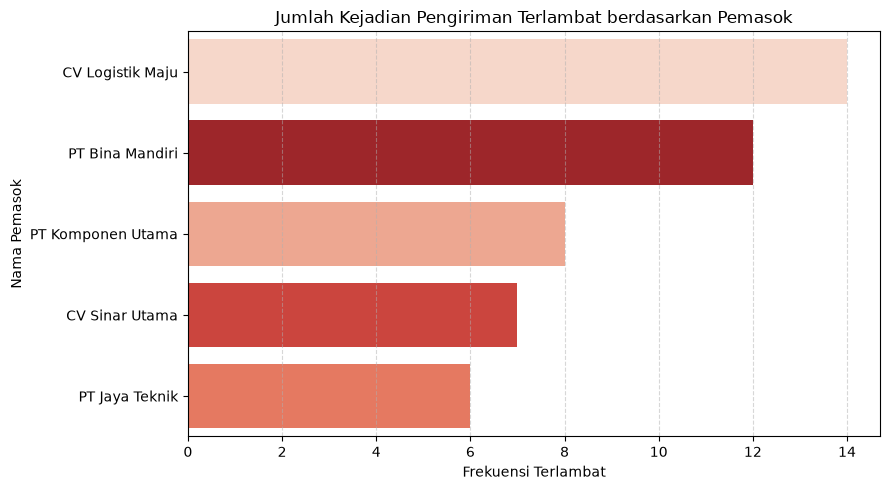

In [4]:
# Visualisasi 1: Jumlah Pengiriman Terlambat Berdasarkan Pemasok
terlambat_df = completed_df[completed_df['Status_Pengiriman'] == 'Terlambat']

plt.figure(figsize=(9, 5))
order_pemasok = terlambat_df['Nama_Pemasok'].value_counts().index
sns.countplot(data=terlambat_df, y='Nama_Pemasok', order=order_pemasok, palette='Reds_r', hue='Nama_Pemasok', legend=False)
plt.title('Jumlah Kejadian Pengiriman Terlambat berdasarkan Pemasok')
plt.xlabel('Frekuensi Terlambat')
plt.ylabel('Nama Pemasok')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight Visualisasi 1:

Grafik ini mengidentifikasi pemasok yang paling sering mengalami keterlambatan pengiriman komponen. Data ini memberikan dasar evaluasi bagi manajemen rantai pasok untuk melakukan negosiasi ulang kontrak atau memberikan peringatan performa kepada vendor dengan frekuensi keterlambatan tertinggi.

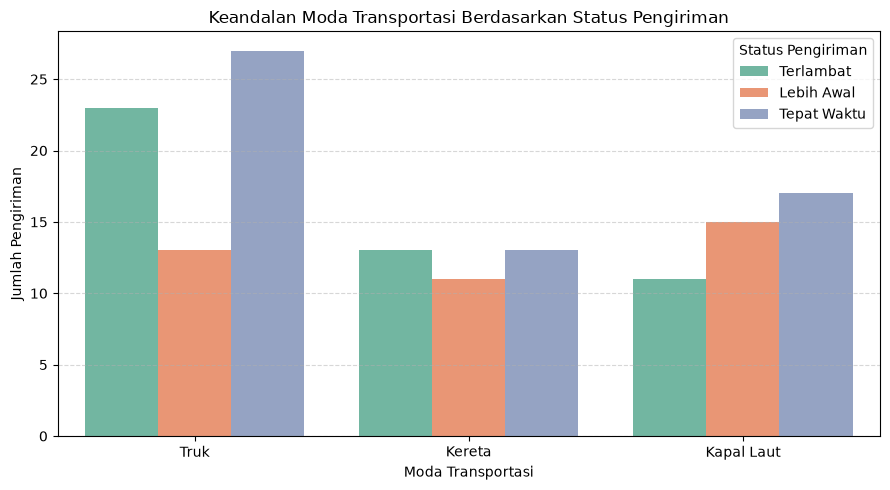

In [5]:
# Visualisasi 2: Countplot Moda Transportasi vs Status Pengiriman
plt.figure(figsize=(9, 5))
sns.countplot(data=completed_df, x='Moda_Transportasi', hue='Status_Pengiriman', palette='Set2')
plt.title('Keandalan Moda Transportasi Berdasarkan Status Pengiriman')
plt.xlabel('Moda Transportasi')
plt.ylabel('Jumlah Pengiriman')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Status Pengiriman')
plt.tight_layout()
plt.show()

Insight Visualisasi 2:

Grafik ini membandingkan keandalan antar-moda transportasi (Truk, Kereta, dan Kapal Laut). Melalui proporsi status pengiriman di setiap moda, perusahaan dapat menentukan moda transportasi mana yang paling andal dalam menjaga ketepatan waktu serta mana yang memiliki risiko keterlambatan tertinggi.

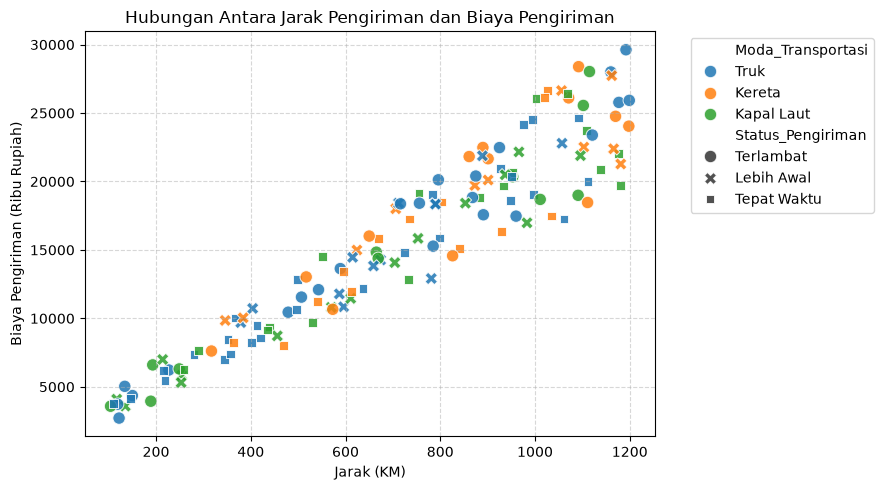

In [6]:
# Visualisasi 3: Scatter Plot Jarak KM vs Biaya Pengiriman
plt.figure(figsize=(9, 5))
sns.scatterplot(data=completed_df, x='Jarak_KM', y='Biaya_Pengiriman_Ribu_Rupiah', hue='Moda_Transportasi', style='Status_Pengiriman', s=80, alpha=0.85)
plt.title('Hubungan Antara Jarak Pengiriman dan Biaya Pengiriman')
plt.xlabel('Jarak (KM)')
plt.ylabel('Biaya Pengiriman (Ribu Rupiah)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight Visualisasi 3:

Scatter plot ini memperlihatkan korelasi positif antara jarak tempuh pengiriman (KM) dengan total biaya pengiriman. Pengelompokan berdasarkan moda transportasi memperjelas efisiensi biaya pada jarak tertentu, serta membantu mengidentifikasi apakah pengiriman yang mengalami keterlambatan cenderung terjadi pada rute jarak jauh.